### Plotting Variational free energy

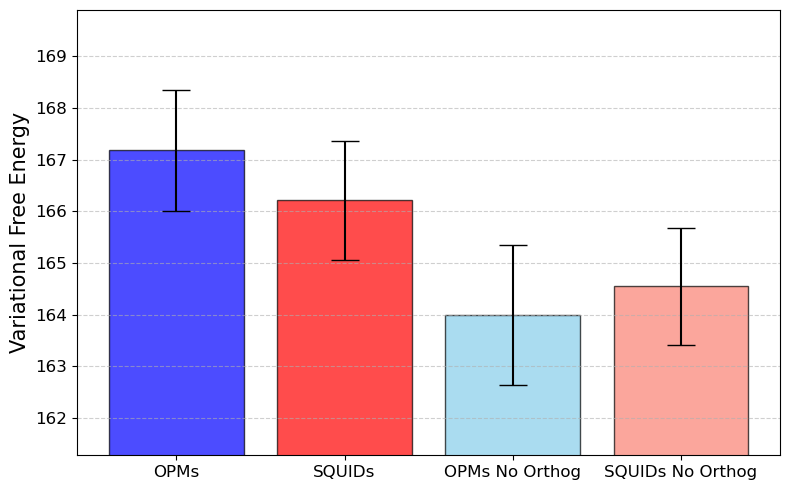

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

def parse_free_energy_file(file_path):
    """Parses the text file and returns a list of free energy values."""
    values = []
    # Regex to match the subject lines: sub-XXX_ses-YYY... = VALUE
    pattern = re.compile(r'sub-\d+_ses-\d+.*=\s*([\d\.]+)')
    
    with open(file_path, 'r') as f:
        for line in f:
            match = pattern.search(line)
            if match:
                values.append(float(match.group(1)))
    return values

# 1. Load your data (Update these filenames to match yours)
file1_path = '/rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/hmm_8state_opms/free_energy.txt'
file2_path = '/rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/hmm_8state_squids/free_energy.txt'
file3_path = '/rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/hmm_8state_opms_noorthog/free_energy.txt'
file4_path = '/rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/hmm_8state_squids_noorthog/free_energy.txt'

# For this example, we assume you have saved the text you provided into these files
data1 = parse_free_energy_file(file1_path)
data2 = parse_free_energy_file(file2_path)
data3 = parse_free_energy_file(file3_path)
data4 = parse_free_energy_file(file4_path)

# 2. Calculate Statistics
means = [np.mean(data1), np.mean(data2), np.mean(data3), np.mean(data4)]
stds = [np.std(data1), np.std(data2), np.std(data3), np.std(data4)]
labels = ['OPMs', 'SQUIDs', 'OPMs No Orthog', 'SQUIDs No Orthog']

# 3. Plotting
plt.figure(figsize=(8, 5))
x_pos = np.arange(len(labels))

# Create bars with error bars
plt.bar(x_pos, means, yerr=stds, align='center', alpha=0.7, 
        color=['blue', 'red', 'skyblue', 'salmon'], capsize=10, edgecolor='black')

plt.xticks(x_pos, labels, fontsize=12)
plt.ylabel('Variational Free Energy', fontsize=15)
plt.yticks(fontsize=12)
#plt.title('Comparison of Variational Free Energy')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Optional: Adjust the y-axis to see differences more clearly
plt.ylim(min(means) - max(stds)*2, max(means) + max(stds)*2)

plt.tight_layout()
plt.show()